In [1]:
!pip install sentence-transformers seaborn matplotlib

In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the match",
    "The bowler took three wickets in one over",
    "The team won the cricket match by 5 runs",
    "The captain made a strategic field placement",

    # Cooking (3)
    "Cooking pasta requires boiling water and adding salt",
    "The chef prepared a delicious Italian dish",
    "Baking a cake needs flour, eggs, and sugar",

    # Cybersecurity (3)
    "Cybersecurity protects systems from digital attacks",
    "Strong passwords help prevent unauthorized access",
    "Encryption ensures data privacy and security"
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


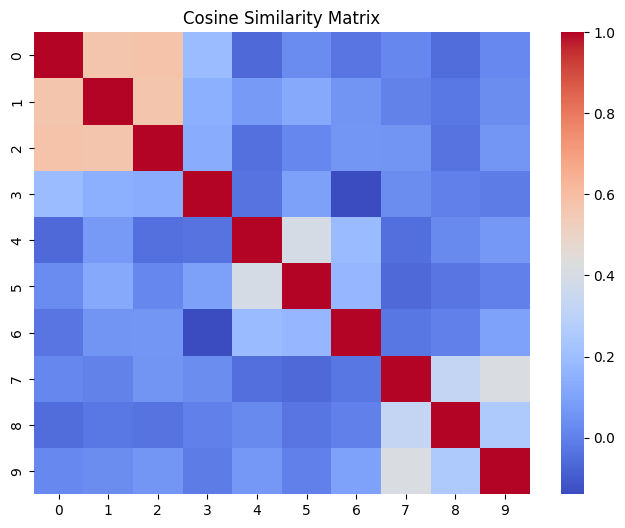

In [5]:
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=False, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

In [6]:
query = "The bowler performed exceptionally well in the match"
query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)[0]

top_indices = scores.argsort()[-3:][::-1]  # includes itself

print("Top 2 most similar sentences:\n")

count = 0
for idx in top_indices:
    if sentences[idx] != query:
        print(f"Sentence: {sentences[idx]}")
        print(f"Similarity Score: {scores[idx]:.4f}\n")
        count += 1
    if count == 2:
        break

Top 2 most similar sentences:

Sentence: The bowler took three wickets in one over
Similarity Score: 0.6321

Sentence: The batsman scored a century in the match
Similarity Score: 0.5359

